<a href="https://colab.research.google.com/github/joseph-2412/fisica-computacional-2026-02/blob/main/Taller%203(minimos%20cuadrados%20fortran).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Parte A. Limpieza de datos

1. Abra `100_mediciones_pendulo_minimos_cuadrados.xlsx` y revise la hoja `Datos_estudiantes`.
2. Ejecute el script de limpieza suministrado por el profesor.
3. Complete sus tres tareas: correcciones justificadas, elección del ángulo máximo y exclusiones manuales.
4. No excluya un dato únicamente porque se aleja de la tendencia. Toda corrección o exclusión debe apoyarse en la información experimental.
5. El script debe generar `pendulo_limpio.dat` e `informe_limpieza.xlsx`.

In [4]:
"""Limpieza de mediciones de un péndulo y exportación para Fortran.

Por favor complete los tres bloques marcados como TODO.
"""

from pathlib import Path

import pandas as pd


# ============================================================
# 1. LECTURA DEL ARCHIVO
# ============================================================

ARCHIVO_ENTRADA = Path("100_mediciones_pendulo_minimos_cuadrados.xlsx")
HOJA = "Datos_estudiantes"

if not ARCHIVO_ENTRADA.exists():
    raise FileNotFoundError(
        f"No se encontró {ARCHIVO_ENTRADA}. "
        "Guarde el script y el archivo de Excel en la misma carpeta."
    )

datos = pd.read_excel(ARCHIVO_ENTRADA, sheet_name=HOJA)

columnas_requeridas = [
    "medicion_id",
    "longitud_cm",
    "angulo_inicial_deg",
    "numero_oscilaciones",
    "tiempo_medido_s",
    "observador",
    "observacion_campo",
    "calidad_video",
]

columnas_ausentes = [
    columna for columna in columnas_requeridas if columna not in datos.columns
]

if columnas_ausentes:
    raise ValueError(
        "Faltan columnas obligatorias en el archivo: "
        + ", ".join(columnas_ausentes)
    )

# Se conserva una copia independiente de los datos originales.
datos_originales = datos.copy(deep=True)

print("\nNúmero inicial de registros:", len(datos))
print("\nPrimeras mediciones:")
print(datos.head())


# ============================================================
# 2. COLUMNAS PARA DOCUMENTAR LA LIMPIEZA
# ============================================================

datos["incluir"] = True
datos["accion_limpieza"] = "Conservar"
datos["justificacion"] = "Medición aceptada"


def excluir_registros(condicion, justificacion):
    """Excluye únicamente registros que todavía estaban aceptados."""
    nuevos = condicion.fillna(False) & datos["incluir"]
    datos.loc[nuevos, "incluir"] = False
    datos.loc[nuevos, "accion_limpieza"] = "Excluir"
    datos.loc[nuevos, "justificacion"] = justificacion


# ============================================================
# 3. CORRECCIONES JUSTIFICADAS
# ============================================================

# Complete los diccionarios con las correcciones que considere
# justificadas. La forma es:

# medicion_id: valor_corregido

# Si no desea corregir ningún registro, deje el diccionario vacío.

correcciones_longitud = {
    52: 70
    # medicion_id: longitud_correcta
}

correcciones_tiempo = {
    # medicion_id: tiempo_total_correcto
}

for medicion_id, valor in correcciones_longitud.items():
    condicion = datos["medicion_id"] == medicion_id

    if not condicion.any():
        print(f"Advertencia: no existe la medición {medicion_id}.")
        continue

    datos.loc[condicion, "longitud_cm"] = valor
    datos.loc[condicion, "accion_limpieza"] = "Corregir longitud"
    datos.loc[condicion, "justificacion"] = (
        "Error de registro identificado y corregido"
    )

for medicion_id, valor in correcciones_tiempo.items():
    condicion = datos["medicion_id"] == medicion_id

    if not condicion.any():
        print(f"Advertencia: no existe la medición {medicion_id}.")
        continue

    datos.loc[condicion, "tiempo_medido_s"] = valor
    datos.loc[condicion, "accion_limpieza"] = "Corregir tiempo"
    datos.loc[condicion, "justificacion"] = (
        "El valor registrado no correspondía al tiempo total"
    )


# ============================================================
# 4. EXCLUSIONES AUTOMÁTICAS
# ============================================================

excluir_registros(
    datos["tiempo_medido_s"].isna(),
    "No existe un tiempo medido",
)

excluir_registros(
    datos["numero_oscilaciones"].isna()
    | (datos["numero_oscilaciones"] <= 0),
    "Número de oscilaciones ausente o no positivo",
)


# ============================================================
# 5. DOMINIO DE VALIDEZ DEL MODELO
# ============================================================

# TODO 2: Ángulo máximo asignado a 10 grados
ANGULO_MAXIMO = 10

if ANGULO_MAXIMO is None:
    raise ValueError(
        "Debe completar TODO 2: asigne un valor numérico a "
        "ANGULO_MAXIMO."
    )

excluir_registros(
    datos["angulo_inicial_deg"].isna()
    | (datos["angulo_inicial_deg"].abs() > ANGULO_MAXIMO),
    "Fuera de la aproximación de ángulo pequeño",
)


# ============================================================
# 6. BÚSQUEDA DE REGISTROS DUPLICADOS
# ============================================================

variables_experimentales = [
    "longitud_cm",
    "angulo_inicial_deg",
    "numero_oscilaciones",
    "tiempo_medido_s",
    "observador",
]

# Solo se buscan duplicados entre registros aún aceptados. Así, un
# registro ya rechazado no provoca la exclusión de una medición válida.
duplicados = pd.Series(False, index=datos.index)
indices_aceptados = datos.index[datos["incluir"]]
duplicados.loc[indices_aceptados] = datos.loc[
    indices_aceptados
].duplicated(subset=variables_experimentales, keep="first")

excluir_registros(
    duplicados,
    "Registro experimental duplicado",
)


# ============================================================
# 7. CÁLCULOS PRELIMINARES E INSPECCIÓN
# ============================================================

# El período se calcula después de aplicar las correcciones.
datos["periodo_preliminar_s"] = (
    datos["tiempo_medido_s"] / datos["numero_oscilaciones"]
)

print("\nLongitudes potencialmente sospechosas:")
print(
    datos.loc[
        (datos["longitud_cm"] < 20) | (datos["longitud_cm"] > 100),
        ["medicion_id", "longitud_cm", "observacion_campo"],
    ]
)

print("\nPeríodos potencialmente sospechosos:")
print(
    datos.loc[
        (datos["periodo_preliminar_s"] < 0.5)
        | (datos["periodo_preliminar_s"] > 3.0),
        [
            "medicion_id",
            "longitud_cm",
            "numero_oscilaciones",
            "tiempo_medido_s",
            "periodo_preliminar_s",
            "observacion_campo",
        ],
    ]
)

print("\nMediciones con calidad de video baja:")
print(
    datos.loc[
        datos["calidad_video"].eq("Baja"),
        ["medicion_id", "calidad_video", "observacion_campo"],
    ]
)


# ============================================================
# 8. EXCLUSIONES QUE REQUIEREN INTERPRETACIÓN
# ============================================================

# TODO 3:
# Agregue las mediciones que deben excluirse por razones
# experimentales que no fueron tratadas automáticamente:
#
# medicion_id: "justificación"

exclusiones_manuales = {
    # medicion_id: "razón de la exclusión"
}

for medicion_id, razon in exclusiones_manuales.items():
    condicion = datos["medicion_id"] == medicion_id

    if not condicion.any():
        print(f"Advertencia: no existe la medición {medicion_id}.")
        continue

    datos.loc[condicion, "incluir"] = False
    datos.loc[condicion, "accion_limpieza"] = "Excluir"
    datos.loc[condicion, "justificacion"] = razon


# ============================================================
# 9. CONSTRUCCIÓN DEL CONJUNTO LIMPIO
# ============================================================

datos_limpios = datos.loc[datos["incluir"]].copy()

print("\nNúmero de registros originales:", len(datos_originales))
print("Número de registros aceptados:", len(datos_limpios))
print("Número de registros excluidos:", len(datos) - len(datos_limpios))


# ============================================================
# 10. ARCHIVO PARA FORTRAN
# ============================================================

columnas_fortran = [
    "medicion_id",
    "longitud_cm",
    "angulo_inicial_deg",
    "numero_oscilaciones",
    "tiempo_medido_s",
]

datos_limpios[columnas_fortran].to_csv(
    "pendulo_limpio.dat",
    sep=" ",
    index=False,
    header=False,
    float_format="%.6f",
)


# ============================================================
# 11. INFORME DE LIMPIEZA
# ============================================================

columnas_informe = [
    "medicion_id",
    "incluir",
    "accion_limpieza",
    "justificacion",
]

datos[columnas_informe].to_excel(
    "informe_limpieza.xlsx",
    index=False,
)

print("\nArchivos generados:")
print("  pendulo_limpio.dat")
print("  informe_limpieza.xlsx")


Número inicial de registros: 100

Primeras mediciones:
   medicion_id  longitud_cm  angulo_inicial_deg  numero_oscilaciones  \
0            1           55                   8                   10   
1            2           90                   5                   10   
2            3           40                   8                   10   
3            4           75                   5                   10   
4            5           25                   8                   10   

   tiempo_medido_s observador calidad_video observacion_campo  
0           14.975        Ana          Alta               NaN  
1           19.135       Luis          Alta               NaN  
2           12.629      María          Alta               NaN  
3           17.416      Jorge          Alta               NaN  
4            9.934        Ana          Alta               NaN  

Longitudes potencialmente sospechosas:
Empty DataFrame
Columns: [medicion_id, longitud_cm, observacion_campo]
Index: []

Perío

# Parte B: Programa en Fortran 2008 (`ajuste_pendulo.f90`)




In [11]:
%%writefile ajuste_pendulo.f90
program ajuste_pendulo
  implicit none

  ! Definición de precisión doble (dp = 8 bytes / 64 bits)
  integer, parameter :: dp = 8
  real(dp), parameter :: pi = 3.14159265358979323846_dp

  ! Variables de lectura de datos
  integer :: id, n_osc
  real(dp) :: longitud_cm, angulo_deg, tiempo_s

  ! Variables de control, cálculo y acumuladores
  integer :: n, unidad_in, unidad_salida, estado
  real(dp) :: longitud_m, x, y, T_periodo
  real(dp) :: sx, sy, sxx, sxy, den, a, b, g, y_prom, y_est, sse, sst, r2

  ! ============================================================================
  ! 1. Abrir `pendulo_limpio.dat` y comprobar que el archivo se abrió correctamente
  ! ============================================================================
  open(newunit=unidad_in, file='pendulo_limpio.dat', status='old', action='read', iostat=estado)
  call validar_archivo(estado)

  ! ============================================================================
  ! 2. Leer un número desconocido de filas mediante un ciclo y `iostat`
  ! ============================================================================
  n = 0
  sx = 0.0_dp
  sy = 0.0_dp
  sxx = 0.0_dp
  sxy = 0.0_dp

  do
    read(unidad_in, *, iostat=estado) id, longitud_cm, angulo_deg, n_osc, tiempo_s
    if (estado /= 0) exit

    ! ==========================================================================
    ! 3. Convertir cada longitud de centímetros a metros
    ! ==========================================================================
    longitud_m = longitud_cm / 100.0_dp

    ! ==========================================================================
    ! 4. Calcular T y construir x = L y y = T^2
    ! ==========================================================================
    T_periodo = tiempo_s / real(n_osc, dp)
    x = longitud_m
    y = T_periodo**2

    ! ==========================================================================
    ! 5. Acumular N, s_x, s_y, s_xx y s_xy
    ! ==========================================================================
    n = n + 1
    sx = sx + x
    sy = sy + y
    sxx = sxx + x*x
    sxy = sxy + x*y
  end do

  ! ============================================================================
  ! 6. Calcular la pendiente a y el intercepto b
  ! ============================================================================
  call validar_datos_y_denominador(n, sxx, sx, den)
  a = (real(n, dp)*sxy - sx*sy) / den
  b = (sy - a*sx) / real(n, dp)

  ! ============================================================================
  ! 7. Estimar g = 4*pi^2 / a
  ! ============================================================================
  g = (4.0_dp * pi**2) / a

  ! ============================================================================
  ! 8. Realizar una segunda lectura del archivo para calcular R^2
  ! ============================================================================
  rewind(unidad_in)
  y_prom = sy / real(n, dp)
  sse = 0.0_dp
  sst = 0.0_dp

  do
    read(unidad_in, *, iostat=estado) id, longitud_cm, angulo_deg, n_osc, tiempo_s
    if (estado /= 0) exit

    longitud_m = longitud_cm / 100.0_dp
    T_periodo = tiempo_s / real(n_osc, dp)
    x = longitud_m
    y = T_periodo**2

    y_est = a*x + b
    sse = sse + (y - y_est)**2
    sst = sst + (y - y_prom)**2
  end do
  close(unidad_in)

  if (sst > 0.0_dp) then
    r2 = 1.0_dp - (sse / sst)
  else
    r2 = 0.0_dp
  end if

  ! ============================================================================
  ! 9. Mostrar claramente N, a, b, R^2 y g, incluyendo unidades
  ! ============================================================================
  print *, "========== RESULTADOS DEL AJUSTE (FORTRAN 2008) =========="
  print '(A, I0)',        "Numero de datos (N):              ", n
  print '(A, F12.6, A)', "Pendiente (a):                    ", a, " s^2/m"
  print '(A, F12.6, A)', "Intercepto (b):                   ", b, " s^2"
  print '(A, F12.6)',    "Coeficiente R^2:                  ", r2
  print '(A, F12.6, A)', "Aceleracion de la gravedad (g):   ", g, " m/s^2"

  ! ============================================================================
  ! 10. Escribir esos cinco valores en resultados_ajuste.dat
  ! ============================================================================
  open(newunit=unidad_salida, file='resultados_ajuste.dat', status='replace', action='write')
  write(unidad_salida, *) n, a, b, r2, g
  close(unidad_salida)

contains

  ! ============================================================================
  ! 11. Detectar errores (archivo inexistente, menos de dos datos y denominador nulo)
  ! ============================================================================
  subroutine validar_archivo(est)
    integer, intent(in) :: est
    if (est /= 0) then
      error stop 'Error (Punto 11): El archivo pendulo_limpio.dat no existe o no se pudo abrir.'
    end if
  end subroutine validar_archivo

  subroutine validar_datos_y_denominador(num, s_xx, s_x, d)
    integer, intent(in) :: num
    real(dp), intent(in) :: s_xx, s_x
    real(dp), intent(out) :: d

    if (num < 2) then
      error stop 'Error (Punto 11): Se requieren al menos dos datos para realizar el ajuste.'
    end if

    d = real(num, dp)*s_xx - s_x*s_x

    if (abs(d) <= tiny(d)) then
      error stop 'Error (Punto 11): Denominador nulo en el calculo de minimos cuadrados.'
    end if
  end subroutine validar_datos_y_denominador

end program ajuste_pendulo

Overwriting ajuste_pendulo.f90


In [15]:
%%writefile pendulo_limpio.dat
1 20.0 5.0 10 9.00
2 40.0 5.0 10 12.70
3 60.0 5.0 10 15.55
4 80.0 5.0 10 17.95
5 100.0 5.0 10 20.07

Overwriting pendulo_limpio.dat


In [16]:
!gfortran -std=f2008 -Wall -Wextra -fcheck=all -o ajuste_pendulo ajuste_pendulo.f90
!./ajuste_pendulo

 ========== RESULTADOS DEL AJUSTE (FORTRAN 2008) ==========
Numero de datos (N):              5
Pendiente (a):                        4.022612 s^2/m
Intercepto (b):                       0.004633 s^2
Coeficiente R^2:                      1.000000
Aceleracion de la gravedad (g):       9.814126 m/s^2


## Parte C. Visualización en Python

Complete la celda para representar $T^2$ en función de $L$, la recta calculada con Fortran y los residuos. No use Python para volver a realizar el ajuste: los valores de `a` y `b` deben proceder de su programa Fortran

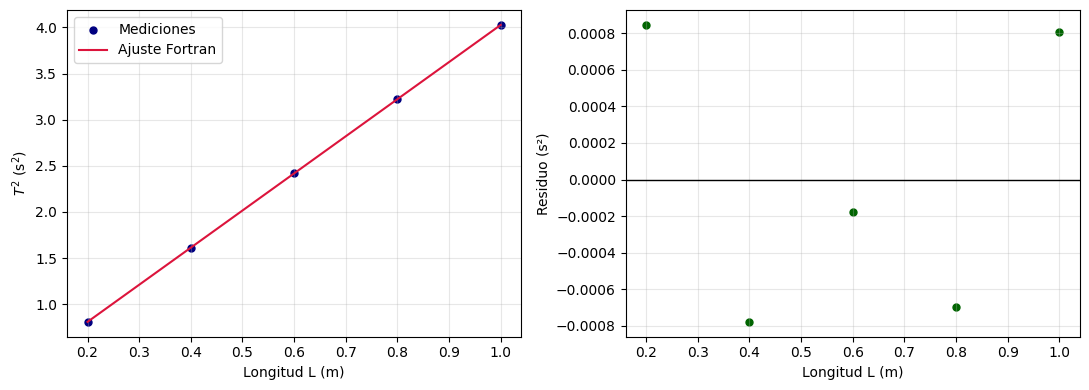

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Lee las cinco columnas producidas por el script de limpieza
datos = np.loadtxt("pendulo_limpio.dat")
longitud_m = datos[:, 1] / 100.0
numero_oscilaciones = datos[:, 3]
tiempo_total_s = datos[:, 4]

# TODO: construya las variables linealizadas x=L y y=T^2
periodo_s = tiempo_total_s / numero_oscilaciones
x = longitud_m
y = periodo_s**2

# Lee los parámetros calculados por el programa Fortran desde resultados_ajuste.dat
resultados_fortran = np.loadtxt("resultados_ajuste.dat")
a = resultados_fortran[1]
b = resultados_fortran[2]

# Ordena x para dibujar una línea continua de izquierda a derecha
orden = np.argsort(x)
y_ajustada = a*x + b
residuos = y - y_ajustada

# Primer panel: mediciones y recta. Segundo panel: residuos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.scatter(x, y, s=25, color="navy", label="Mediciones")
ax1.plot(x[orden], y_ajustada[orden], color="crimson", label="Ajuste Fortran")
ax1.set_xlabel("Longitud L (m)")
ax1.set_ylabel(r"$T^2$ (s$^2$)")
ax1.grid(alpha=0.3)
ax1.legend()

ax2.axhline(0.0, color="black", linewidth=1)
ax2.scatter(x, residuos, s=25, color="darkgreen")
ax2.set_xlabel("Longitud L (m)")
ax2.set_ylabel("Residuo (s²)")
ax2.grid(alpha=0.3)

plt.tight_layout()
# Guarda la figura que se entregará con el informe
plt.savefig("ajuste_pendulo_y_residuos.png", dpi=200, bbox_inches="tight")
plt.show()